In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# IMDB Movie Review Sentiment Analysis

Binary sentiment classification (positive / negative) of 50,000 IMDB movie reviews using classical machine learning.

**Dataset:** IMDB Dataset of 50K Movie Reviews (Kaggle: lakshmi25npathi/imdb-dataset-of-50k-movie-reviews), balanced 25,000 positive / 25,000 negative.

**Approach**
1. Exploratory data analysis
2. Text preprocessing: HTML removal, lowercasing, contraction expansion, negation handling (`not_x` tokens), stopword removal, lemmatization
3. TF-IDF features: 4 configurations (unigram, unigram + sublinear TF, bigram, trigram)
4. Models: LinearSVC, Logistic Regression, Multinomial Naive Bayes (12 combinations)
5. Hyperparameter tuning, 5-fold cross-validation, feature analysis, error analysis

**Headline result:** TF-IDF trigrams + sublinear TF + LinearSVC (C=1.0) reached 91.10% test accuracy and 90.69% +/- 0.18 in 5-fold cross-validation.

In [1]:
!pip install contractions -q

import pandas as pd
import numpy as np
import re
import time
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

np.random.seed(42)

stop_words = set(stopwords.words('english'))
for w in ['not', 'no', 'never', 'nor']:
    stop_words.discard(w)

print('not' in stop_words, 'no' in stop_words, 'never' in stop_words, 'nor' in stop_words)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 7.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.3 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...


False False False False


[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [4]:
df = pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

print("Shape:", df.shape)
print()
print(df.head())
print()
print(df['sentiment'].value_counts())
print()
print("Null values:\n", df.isnull().sum())

Shape: (50000, 2)

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Null values:
 review       0
sentiment    0
dtype: int64


In [5]:
for label in ['positive', 'negative']:
    print(f'\n===== {label.upper()} =====')
    for r in df[df['sentiment'] == label].sample(3, random_state=1)['review']:
        print(r[:500])
        print('---')


===== POSITIVE =====
There is a story (possibly apocryphal) about an exchange between Bruce Willis and Terry Gilliam at the start of Twelve Monkeys. Gilliam (allegedly) produced a long list (think about the aircraft one from the Fifth Element) and handed it to Butch Bruce. It was entitled "Things Bruce Willis Does When He Acts". It ended with a simple message saying: "please don't do any of the above in my movie".<br /><br />There is a fact about this movie (definitely true). Gilliam didn't have a hand in the writin
---
This game is an action/adventure with combat. There are quite long periods with no combat but other times, you have to get rid of various kinds of monsters. The monsters are not like anything you would see in real life, and they have to be gotten rid off in order to continue with your quest. The whole game is a quest. You play Adam Randall whose father contacts him from the beyond and asks him to come and save him. The game is from the mid 1990's and has to be played i

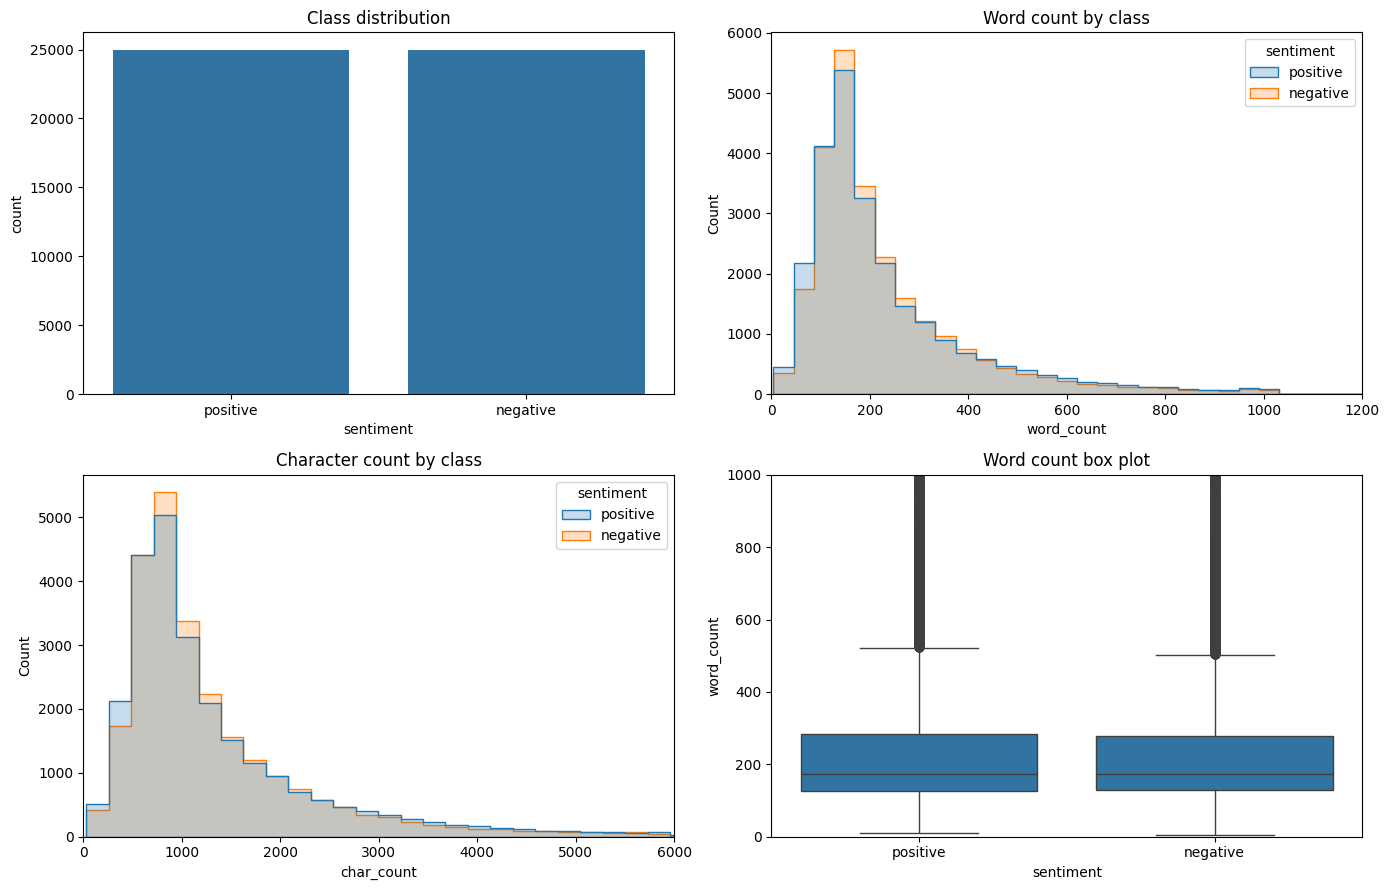

          word_count               char_count              
                mean median   max        mean median    max
sentiment                                                  
negative   229.46456  174.0  1522  1294.06436  973.0   8969
positive   232.84932  172.0  2470  1324.79768  968.0  13704


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

df['word_count'] = df['review'].apply(lambda x: len(x.split()))
df['char_count'] = df['review'].apply(len)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.countplot(data=df, x='sentiment', ax=axes[0, 0])
axes[0, 0].set_title('Class distribution')

sns.histplot(data=df, x='word_count', hue='sentiment', bins=60,
             element='step', ax=axes[0, 1])
axes[0, 1].set_xlim(0, 1200)
axes[0, 1].set_title('Word count by class')

sns.histplot(data=df, x='char_count', hue='sentiment', bins=60,
             element='step', ax=axes[1, 0])
axes[1, 0].set_xlim(0, 6000)
axes[1, 0].set_title('Character count by class')

sns.boxplot(data=df, x='sentiment', y='word_count', ax=axes[1, 1])
axes[1, 1].set_ylim(0, 1000)
axes[1, 1].set_title('Word count box plot')

plt.tight_layout()
plt.show()

print(df.groupby('sentiment')[['word_count', 'char_count']].agg(['mean', 'median', 'max']))

Reviews with <br />: 58.4%
Reviews with any HTML tag: 58.4%


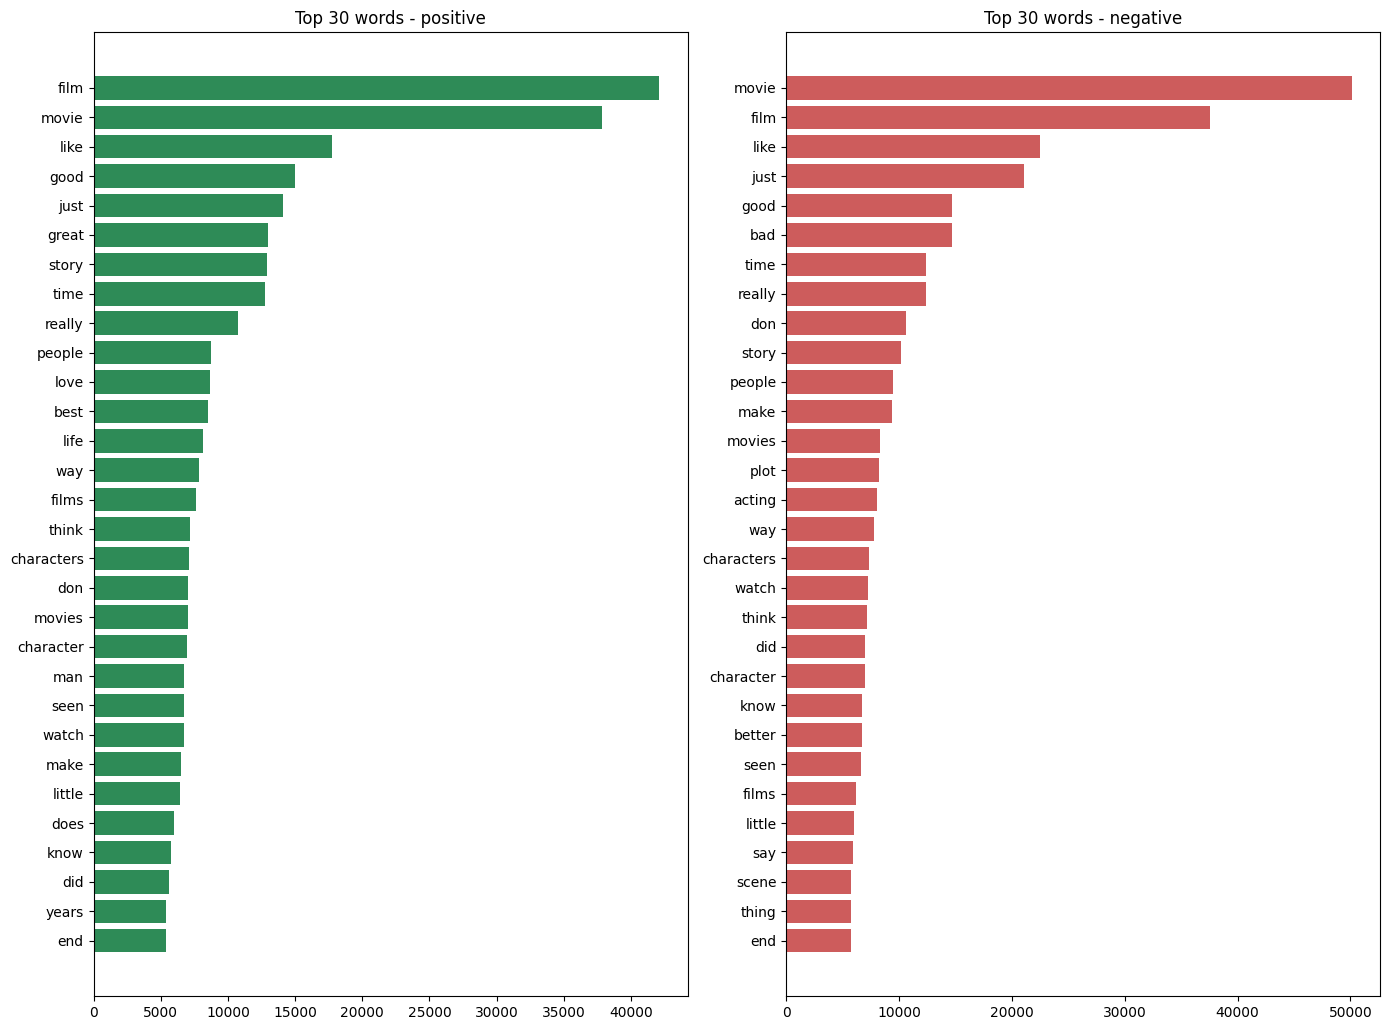

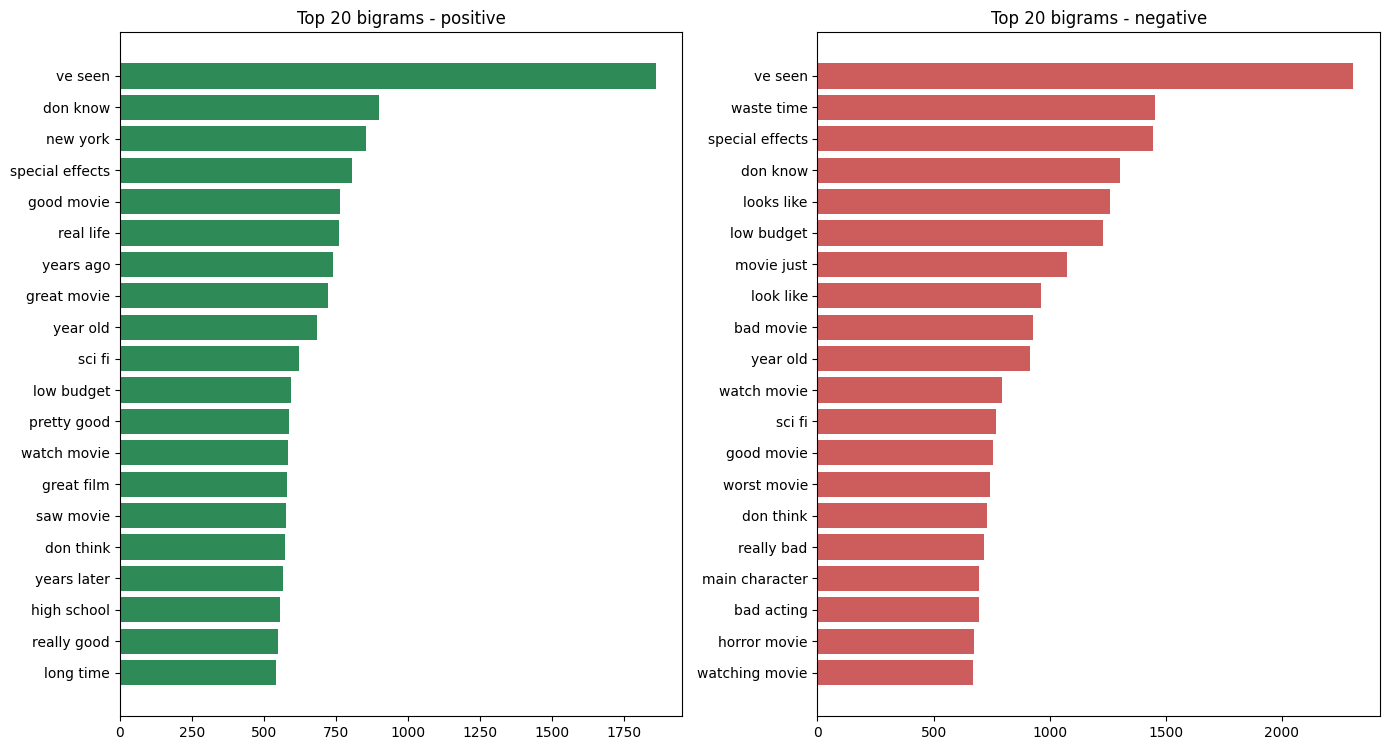

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

pct_br = df['review'].str.contains('<br />', regex=False).mean() * 100
pct_tag = df['review'].str.contains(r'<[^>]+>', regex=True).mean() * 100
print(f"Reviews with <br />: {pct_br:.1f}%")
print(f"Reviews with any HTML tag: {pct_tag:.1f}%")

def basic_clean(t):
    t = re.sub(r'<.*?>', ' ', t)
    t = t.lower()
    t = re.sub(r'[^a-z\s]', ' ', t)
    return t

df['basic'] = df['review'].apply(basic_clean)

def top_ngrams(texts, ngram, n):
    cv = CountVectorizer(ngram_range=(ngram, ngram), stop_words='english', min_df=5)
    X = cv.fit_transform(texts)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    names = cv.get_feature_names_out()
    idx = freqs.argsort()[::-1][:n]
    return [(names[i], int(freqs[i])) for i in idx]

def plot_top(ngram, n, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 0.28 * n + 2))
    for ax, label, color in zip(axes, ['positive', 'negative'], ['seagreen', 'indianred']):
        items = top_ngrams(df[df['sentiment'] == label]['basic'], ngram, n)
        words, counts = zip(*items)
        ax.barh(words[::-1], counts[::-1], color=color)
        ax.set_title(f'{title} - {label}')
    plt.tight_layout()
    plt.show()

plot_top(1, 30, 'Top 30 words')
plot_top(2, 20, 'Top 20 bigrams')

In [8]:
def avg_sentence_len(t):
    t = re.sub(r'<.*?>', ' ', t)
    sents = [s for s in re.split(r'[.!?]+', t) if s.strip()]
    return len(t.split()) / max(len(sents), 1)

df['avg_sent_len'] = df['review'].apply(avg_sentence_len)
print(df.groupby('sentiment')['avg_sent_len'].mean())

sentiment
negative    17.645415
positive    18.557007
Name: avg_sent_len, dtype: float64


## EDA Findings

- **Class balance:** The dataset is perfectly balanced (25,000 positive / 25,000 negative), so accuracy is a valid primary metric.
- **Review length:** Positive reviews average 232.8 words and negative reviews 229.5 (medians 172 and 174). The distributions are almost identical and right-skewed, so length is a very weak signal.
- **HTML issue:** 58.4% of reviews contain `<br />` tags. They must be stripped first, otherwise "br" becomes a high-frequency token with no sentiment value.
- **Vocabulary:** "movie", "film", "like" and "just" dominate both classes. "good" is frequent in both, so raw frequency alone cannot separate sentiment. "great", "love", "best" lean positive and "bad" leans negative.
- **Bigrams:** Negative reviews show phrases like "waste time", "worst movie", "bad movie", "really bad" and "bad acting". This shows multi-word phrases carry sentiment, motivating bigrams and trigrams in TF-IDF.
- **Contractions and negation:** Fragments like "don", "ve" ("don know", "ve seen") appear because apostrophes were stripped, which destroys negations such as "don't". This motivates expanding contractions and handling negation explicitly ("not good" -> "not_good").

In [9]:
import html
import contractions
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

NEG_RE = re.compile(r"\b(?:not|never|no|cannot)\s+(?:(?:a|an|the|very|really|so|too|even|that)\s+)?([a-z]+)")

def wn_pos(tag):
    if tag.startswith('J'): return 'a'
    if tag.startswith('V'): return 'v'
    if tag.startswith('R'): return 'r'
    return 'n'

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)        # 1. HTML tags hatao
    text = html.unescape(text)                # 1. HTML entities
    text = text.lower()                       # 2. lowercase
    text = contractions.fix(text)             # 3. don't -> do not
    text = NEG_RE.sub(r'not_\1', text)        # 4. negation handling
    text = re.sub(r'[^a-z_\s]', ' ', text)    # 5. punctuation + numbers hatao
    tokens = text.split()                     # 6. tokenise
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]  # 7. stopwords (negation kept)
    tagged = pos_tag(tokens)
    out = []
    for w, tag in tagged:                     # 8. lemmatise (POS ke saath)
        out.append(w if '_' in w else lemmatizer.lemmatize(w, wn_pos(tag)))
    return ' '.join(out)                      # 9. rejoin

examples = [
    "This movie was NOT good at all.<br /><br />I don't like the acting.",
    "Not bad at all, actually quite enjoyable! Never disappoints.",
    "The worst film I've seen; better than nothing? No way.",
    "A brilliant, wonderful masterpiece &amp; the best of 2010.",
    "Terribly boring... it isn't funny and the plot wasn't believable.",
]
for e in examples:
    print("BEFORE:", e)
    print("AFTER :", clean_text(e))
    print()

BEFORE: This movie was NOT good at all.<br /><br />I don't like the acting.
AFTER : movie not_good not_like act

BEFORE: Not bad at all, actually quite enjoyable! Never disappoints.
AFTER : not_bad actually quite enjoyable not_disappoints

BEFORE: The worst film I've seen; better than nothing? No way.
AFTER : bad film see well nothing not_way

BEFORE: A brilliant, wonderful masterpiece &amp; the best of 2010.
AFTER : brilliant wonderful masterpiece best

BEFORE: Terribly boring... it isn't funny and the plot wasn't believable.
AFTER : terribly bore not_funny plot not_believable



In [10]:
sample = df.sample(2000, random_state=42)

start = time.time()
sample_clean = sample['review'].apply(clean_text)
elapsed = time.time() - start
print(f"2000 reviews: {elapsed:.1f} sec")
print(f"Estimated for 50,000: {elapsed * 25 / 60:.1f} minutes")

from collections import Counter
c = Counter(w for t in sample_clean for w in t.split() if w.startswith('not_'))
print(c.most_common(25))

2000 reviews: 16.2 sec
Estimated for 50,000: 6.8 minutes
[('not_have', 197), ('not_be', 143), ('not_know', 141), ('not_get', 126), ('not_to', 122), ('not_one', 112), ('not_only', 110), ('not_seen', 80), ('not_think', 75), ('not_good', 75), ('not_like', 72), ('not_want', 64), ('not_as', 61), ('not_see', 59), ('not_make', 57), ('not_just', 56), ('not_bad', 56), ('not_believe', 54), ('not_much', 53), ('not_matter', 50), ('not_been', 49), ('not_do', 45), ('not_for', 44), ('not_help', 43), ('not_sure', 43)]


In [11]:
import html
import contractions
from collections import Counter
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

NEG_RE = re.compile(r"\b(not|never|no|cannot)\s+((?:(?:a|an|the|very|really|so|too|even|that)\s+)?)([a-z]+)")
SKIP = stop_words | {'one', 'much', 'not', 'no', 'never', 'cannot'}

def negate(m):
    nxt = m.group(3)
    if nxt in SKIP:
        return m.group(0)
    return 'not_' + nxt

def wn_pos(tag):
    if tag.startswith('J'): return 'a'
    if tag.startswith('V'): return 'v'
    if tag.startswith('R'): return 'r'
    return 'n'

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)
    text = html.unescape(text)
    text = text.lower()
    text = contractions.fix(text)
    text = NEG_RE.sub(negate, text)
    text = re.sub(r'[^a-z_\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    tagged = pos_tag(tokens)
    out = []
    for w, tag in tagged:
        out.append(w if '_' in w else lemmatizer.lemmatize(w, wn_pos(tag)))
    return ' '.join(out)

sample = df.sample(2000, random_state=42)
sample_clean = sample['review'].apply(clean_text)
c = Counter(w for t in sample_clean for w in t.split() if w.startswith('not_'))
print(c.most_common(25))

[('not_know', 141), ('not_get', 126), ('not_seen', 80), ('not_think', 75), ('not_good', 75), ('not_like', 72), ('not_want', 64), ('not_see', 59), ('not_make', 57), ('not_bad', 56), ('not_believe', 54), ('not_matter', 50), ('not_help', 43), ('not_sure', 43), ('not_say', 42), ('not_care', 41), ('not_need', 40), ('not_seem', 40), ('not_quite', 38), ('not_watch', 38), ('not_worth', 36), ('not_waste', 36), ('not_work', 32), ('not_funny', 32), ('not_enough', 30)]


In [12]:
from tqdm.auto import tqdm
tqdm.pandas()

df['clean'] = df['review'].progress_apply(clean_text)
df.to_pickle('/kaggle/working/df_clean.pkl')

print("Shape:", df.shape)
print("Empty cleaned reviews:", (df['clean'].str.strip() == '').sum())

for s in ['positive', 'negative']:
    print(f"\n--- {s.upper()} ---")
    for t in df[df['sentiment'] == s]['clean'].head(5):
        print(t[:300])
        print()

  0%|          | 0/50000 [00:00<?, ?it/s]

Shape: (50000, 7)
Empty cleaned reviews: 0

--- POSITIVE ---
one reviewer mention watch oz episode hook right exactly happen first thing strike oz brutality unflinching scene violence set right word go trust not_show faint hearted timid show pull not_punches regard drug sex violence hardcore classic use word call oz nickname give oswald maximum security state

wonderful little production film technique unassuming old time bbc fashion give comfort sometimes discomforting sense realism entire piece actor extremely well choose michael sheen not get polari voice pat truly see seamless edit guided reference williams diary entry not well worth watch terrificly 

think wonderful way spend time hot summer weekend sit air condition theater watch light hearted comedy plot simplistic dialogue witty character likable even well bread suspect serial killer may disappoint realize not_match point risk addiction think proof woody allen still fully control style many u

petter mattei love time money vis

In [13]:
import re
from collections import Counter

df['has_neg'] = df['clean'].str.contains(r'\bnot_', regex=True)

print(f"Reviews with at least one not_ token: {df['has_neg'].mean()*100:.1f}%")
print("\nBy class (%):")
print((df.groupby('sentiment')['has_neg'].mean() * 100).round(1))

all_neg = Counter(w for t in df['clean'] for w in t.split() if w.startswith('not_'))
print("\nTotal not_ tokens:", sum(all_neg.values()))
print("Unique not_ tokens:", len(all_neg))
print("\nTop 30:")
print(all_neg.most_common(30))

print("\nHow many reviews contain each token:")
for tok in ['not_good', 'not_bad', 'not_funny', 'not_worth', 'not_like']:
    pat = r'\b' + tok + r'\b'
    p = df[df['sentiment'] == 'positive']['clean'].str.contains(pat, regex=True).sum()
    n = df[df['sentiment'] == 'negative']['clean'].str.contains(pat, regex=True).sum()
    print(f"{tok}: positive={p}, negative={n}")

Reviews with at least one not_ token: 81.0%

By class (%):
sentiment
negative    86.3
positive    75.8
Name: has_neg, dtype: float64

Total not_ tokens: 124210
Unique not_ tokens: 9168

Top 30:
[('not_know', 3844), ('not_get', 2760), ('not_seen', 2012), ('not_think', 1931), ('not_like', 1780), ('not_make', 1645), ('not_see', 1579), ('not_want', 1430), ('not_good', 1349), ('not_believe', 1336), ('not_bad', 1311), ('not_help', 1123), ('not_matter', 1120), ('not_care', 1046), ('not_seem', 1038), ('not_understand', 1024), ('not_watch', 995), ('not_sure', 985), ('not_quite', 967), ('not_funny', 925), ('not_say', 838), ('not_go', 826), ('not_enough', 800), ('not_work', 757), ('not_waste', 757), ('not_worth', 749), ('not_take', 740), ('not_going', 732), ('not_find', 692), ('not_idea', 683)]

How many reviews contain each token:
not_good: positive=291, negative=978
not_bad: positive=421, negative=795
not_funny: positive=74, negative=755
not_worth: positive=55, negative=664
not_like: positive=8

In [14]:
import re

def show(word, sentiment, n=8):
    pat = re.compile(
        r".{0,60}(?:\bnot|\bno|\bnever|n't)\s+(?:(?:a|an|the|very|really|so|too|even|that)\s+)?"
        + word + r"\b.{0,40}", re.I)
    print(f"\n=== '{word}' in {sentiment} reviews ===")
    shown = 0
    for text in df[df['sentiment'] == sentiment]['review'].sample(frac=1, random_state=1):
        text = re.sub(r'<.*?>', ' ', text)
        m = pat.search(text)
        if m:
            print("-", m.group(0).strip())
            shown += 1
        if shown == n:
            break

show('bad', 'negative')
show('like', 'positive')


=== 'bad' in negative reviews ===
- . The look and feel of some of the scenes in this movie are not too bad to be honest. The set-ups are okay in s
- which I use the term loosely, Fredrik Wenzel. the acting isn't too bad. I would give this a 4.5 out of 10 but
- h industry veterans, Marks also having been a director, and not a bad one. Why they got involved in this stea
- he monsters up close, in your face. The graphics really weren't bad, but I would have liked more things to
- ntal music was terrible and drowned out the dialogue (maybe not a bad thing then), and the shots of San Franc
- rasinski is funny and want to see him do well. The story wasn't bad either, just not very original. But the
- ealize that someone was taking this seriously. The story wasn't bad but the inclusion of the SASS members s
- by "breaking them down first, and then building them up."  Not a bad subject. Photography OK. But the plot i

=== 'like' in positive reviews ===
- e to get rid of various kinds of mons

## Negation Analysis Findings

- 81.0% of reviews contain at least one `not_` token (86.3% negative, 75.8% positive).
- `not_good`, `not_funny`, `not_worth` appear mostly in negative reviews, as expected.
- `not_bad` appears in both classes (421 positive, 795 negative). Manual inspection shows it is mostly mild praise ("wasn't bad") that negative reviewers concede before a "but".
- `not_like` is almost balanced (863 positive, 744 negative). It often appears in comparisons ("not like other movies"), in other people's opinions, or in conditionals.
- Limitation: a bag-of-words model cannot tell whose opinion a negation refers to, or that a later "but" reverses the sentiment.

In [16]:
from sklearn.model_selection import train_test_split

df['label'] = (df['sentiment'] == 'positive').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    df['clean'], df['label'],
    test_size=0.2, stratify=df['label'], random_state=42
)

print("Train:", len(X_train), "| Test:", len(X_test))
print("Train class counts:\n", y_train.value_counts())
print("Test class counts:\n", y_test.value_counts())

Train: 40000 | Test: 10000
Train class counts:
 label
1    20000
0    20000
Name: count, dtype: int64
Test class counts:
 label
0    5000
1    5000
Name: count, dtype: int64


In [17]:
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

configs = {
    'Unigram':            dict(ngram_range=(1,1), max_features=20000, sublinear_tf=False),
    'Unigram+sublinear':  dict(ngram_range=(1,1), max_features=20000, sublinear_tf=True),
    'Bigram+sublinear':   dict(ngram_range=(1,2), max_features=30000, sublinear_tf=True),
    'Trigram+sublinear':  dict(ngram_range=(1,3), max_features=50000, sublinear_tf=True),
}

vectorizers, X_tr, X_te = {}, {}, {}
results = {}   # (config, algorithm) -> accuracy

for name, params in configs.items():
    t0 = time.time()
    vec = TfidfVectorizer(min_df=3, max_df=0.90, **params)
    Xtr = vec.fit_transform(X_train)
    Xte = vec.transform(X_test)
    vec_time = time.time() - t0

    t1 = time.time()
    svm = LinearSVC(C=1.0, random_state=42)
    svm.fit(Xtr, y_train)
    acc = accuracy_score(y_test, svm.predict(Xte))
    train_time = time.time() - t1

    vectorizers[name], X_tr[name], X_te[name] = vec, Xtr, Xte
    results[(name, 'LinearSVC')] = acc

    print(f"{name:20s} features={Xtr.shape[1]:6d}  accuracy={acc*100:.2f}%  "
          f"(vectorize {vec_time:.0f}s, train {train_time:.0f}s)")

Unigram              features= 20000  accuracy=89.98%  (vectorize 7s, train 2s)
Unigram+sublinear    features= 20000  accuracy=90.12%  (vectorize 7s, train 2s)
Bigram+sublinear     features= 30000  accuracy=90.98%  (vectorize 32s, train 2s)
Trigram+sublinear    features= 50000  accuracy=91.10%  (vectorize 65s, train 1s)


## TF-IDF Configuration Results (LinearSVC, C=1.0, single 80/20 split)

| Config | Accuracy |
|---|---|
| Unigram (20K features) | 89.98% |
| Unigram + sublinear_tf | 90.12% |
| Bigram + sublinear (30K) | 90.98% |
| Trigram + sublinear (50K) | 91.10% |

- Sublinear TF added +0.14 points, and trigrams added +0.12 over bigrams. Both are within the expected noise (about ±0.3 points on a 10,000-review test set), so they are not conclusive on this split.
- Adding bigrams gave the clearest gain (+0.86 points).
- Total gain from unigram to trigram: +1.12 points.
- max_features also increased with n-gram size, so n-gram order and vocabulary size are confounded.
- LinearSVC trains in 1-2 seconds; TF-IDF vectorization is the slow step (65 s for trigrams).

In [18]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

for name in configs:
    Xtr, Xte = X_tr[name], X_te[name]

    t0 = time.time()
    lr = LogisticRegression(solver='lbfgs', C=1.0, max_iter=1000)
    lr.fit(Xtr, y_train)
    results[(name, 'LogisticRegression')] = accuracy_score(y_test, lr.predict(Xte))
    lr_time = time.time() - t0

    t0 = time.time()
    nb = MultinomialNB(alpha=1.0)
    nb.fit(Xtr, y_train)
    results[(name, 'MultinomialNB')] = accuracy_score(y_test, nb.predict(Xte))
    nb_time = time.time() - t0

    print(f"{name:20s} LogReg {results[(name,'LogisticRegression')]*100:.2f}% ({lr_time:.0f}s) | "
          f"NB {results[(name,'MultinomialNB')]*100:.2f}% ({nb_time:.0f}s)")

table = pd.Series(results).unstack() * 100
table = table[['LinearSVC', 'LogisticRegression', 'MultinomialNB']].loc[list(configs)]
print("\nAccuracy (%) - 4 configs x 3 algorithms:")
print(table.round(2))

Unigram              LogReg 90.00% (1s) | NB 86.95% (0s)
Unigram+sublinear    LogReg 90.26% (1s) | NB 87.21% (0s)
Bigram+sublinear     LogReg 90.69% (2s) | NB 88.53% (0s)
Trigram+sublinear    LogReg 90.59% (2s) | NB 88.91% (0s)

Accuracy (%) - 4 configs x 3 algorithms:
                   LinearSVC  LogisticRegression  MultinomialNB
Unigram                89.98               90.00          86.95
Unigram+sublinear      90.12               90.26          87.21
Bigram+sublinear       90.98               90.69          88.53
Trigram+sublinear      91.10               90.59          88.91


## Algorithm Comparison (4 TF-IDF configs x 3 algorithms, single 80/20 split)

| Config | LinearSVC | LogReg | MultinomialNB |
|---|---|---|---|
| Unigram | 89.98 | 90.00 | 86.95 |
| Unigram + sublinear | 90.12 | 90.26 | 87.21 |
| Bigram + sublinear | 90.98 | 90.69 | 88.53 |
| Trigram + sublinear | 91.10 | 90.59 | 88.91 |

- Best combination: LinearSVC + trigrams (91.10%).
- LinearSVC and LogReg are close (differences of -0.14 to +0.51 points); most gaps are within the expected ±0.3 point noise on a 10,000-review test set.
- Naive Bayes is 2-3 points behind but gains the most from n-grams (+1.96 points from unigram to trigram).
- Sublinear TF gave a small gain for all three algorithms (+0.14 to +0.26 points).
  

In [19]:
import tempfile, shutil
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

cache_dir = tempfile.mkdtemp()

pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,3), max_features=50000,
                              sublinear_tf=True, min_df=3, max_df=0.90)),
    ('clf', LinearSVC(random_state=42)),
], memory=cache_dir)

param_grid = {'clf__C': [0.01, 0.1, 1.0, 10.0]}

t0 = time.time()
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=1)
grid.fit(X_train, y_train)
print(f"Grid search took {(time.time()-t0)/60:.1f} min")

print("\nBest C:", grid.best_params_['clf__C'])
print(f"Best CV accuracy: {grid.best_score_*100:.2f}%")

print("\nAll C values (mean CV accuracy +/- std):")
for c, m, s in zip(param_grid['clf__C'],
                   grid.cv_results_['mean_test_score'],
                   grid.cv_results_['std_test_score']):
    print(f"  C={c:<6} {m*100:.2f}% +/- {s*100:.2f}")

test_acc = accuracy_score(y_test, grid.predict(X_test))
print(f"\nTest accuracy with best C: {test_acc*100:.2f}%")

shutil.rmtree(cache_dir, ignore_errors=True)

Grid search took 6.3 min

Best C: 1.0
Best CV accuracy: 90.46%

All C values (mean CV accuracy +/- std):
  C=0.01   87.41% +/- 0.40
  C=0.1    90.31% +/- 0.28
  C=1.0    90.46% +/- 0.25
  C=10.0   89.21% +/- 0.20

Test accuracy with best C: 91.10%


## Hyperparameter Tuning (LinearSVC, trigram + sublinear, 5-fold CV on the training set)

| C | Mean CV accuracy | Std |
|---|---|---|
| 0.01 | 87.41% | 0.40 |
| 0.1 | 90.31% | 0.28 |
| 1.0 | 90.46% | 0.25 |
| 10.0 | 89.21% | 0.20 |

- Best C = 1.0 (CV accuracy 90.46%). C = 0.1 is within one standard deviation, so the two are effectively tied.
- C = 0.01 likely underfits (too much regularisation); C = 10 loses accuracy, consistent with overfitting to rare vocabulary.
- Test accuracy with C = 1.0 is 91.10%, 0.64 points above the CV mean. CV folds train on 32,000 reviews instead of 40,000, and the 10,000-review test set carries about ±0.3 points of noise.

In [20]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

best_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,3), max_features=50000,
                              sublinear_tf=True, min_df=3, max_df=0.90)),
    ('clf', LinearSVC(C=1.0, random_state=42)),
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

t0 = time.time()
scores = cross_val_score(best_pipe, df['clean'], df['label'],
                         cv=skf, scoring='accuracy', n_jobs=1)
print(f"CV took {(time.time()-t0)/60:.1f} min")
print("Fold accuracies:", [f"{s*100:.2f}%" for s in scores])
print(f"Mean: {scores.mean()*100:.2f}% +/- {scores.std()*100:.2f}")

best_pipe.fit(X_train, y_train)
final_acc = accuracy_score(y_test, best_pipe.predict(X_test))
print(f"\nFinal pipeline (trained on 40,000) test accuracy: {final_acc*100:.2f}%")

CV took 4.8 min
Fold accuracies: ['90.60%', '90.94%', '90.45%', '90.86%', '90.61%']
Mean: 90.69% +/- 0.18

Final pipeline (trained on 40,000) test accuracy: 91.10%


## 5-Fold Cross-Validation (best pipeline: TF-IDF trigrams + sublinear + LinearSVC, C=1.0)

- Fold accuracies: 90.60%, 90.94%, 90.45%, 90.86%, 90.61%
- Mean accuracy: 90.69% +/- 0.18
- Test accuracy of the final pipeline trained on the 40,000-review training set: 91.10%.
- The test result is 0.41 points above the CV mean and above every fold, so the 80/20 split was slightly favourable. 90.7% is the more conservative estimate of true performance.

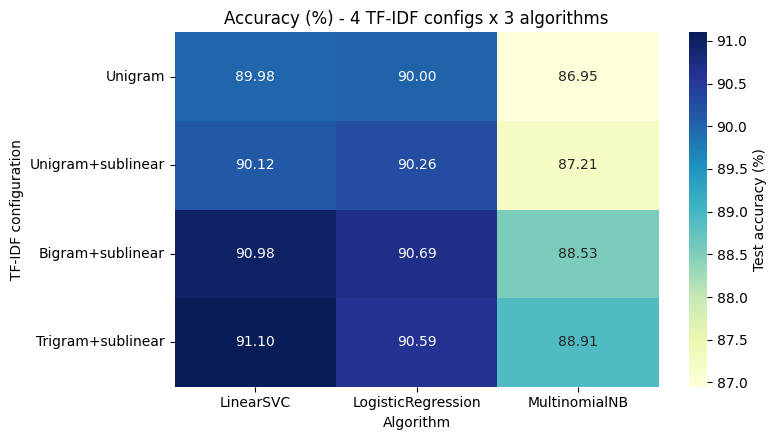

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4.5))
sns.heatmap(table, annot=True, fmt='.2f', cmap='YlGnBu',
            cbar_kws={'label': 'Test accuracy (%)'})
plt.title('Accuracy (%) - 4 TF-IDF configs x 3 algorithms')
plt.ylabel('TF-IDF configuration')
plt.xlabel('Algorithm')
plt.tight_layout()
plt.savefig('/kaggle/working/accuracy_heatmap.png', dpi=150)
plt.show()


=== Top 15 UNIGRAMS -> POSITIVE ===
[('great', np.float64(3.42)), ('excellent', np.float64(3.42)), ('perfect', np.float64(2.7)), ('hilarious', np.float64(2.45)), ('wonderful', np.float64(2.45)), ('fun', np.float64(2.44)), ('enjoyable', np.float64(2.28)), ('brilliant', np.float64(2.24)), ('not_perfect', np.float64(2.17)), ('enjoy', np.float64(2.17)), ('refresh', np.float64(2.11)), ('today', np.float64(2.1)), ('wonderfully', np.float64(2.1)), ('perfectly', np.float64(2.09)), ('best', np.float64(2.08))]

=== Top 15 UNIGRAMS -> NEGATIVE ===
[('bad', np.float64(-5.04)), ('awful', np.float64(-4.18)), ('waste', np.float64(-3.32)), ('not_funny', np.float64(-3.26)), ('poor', np.float64(-2.9)), ('dull', np.float64(-2.85)), ('terrible', np.float64(-2.82)), ('boring', np.float64(-2.77)), ('disappointment', np.float64(-2.77)), ('disappointing', np.float64(-2.77)), ('lack', np.float64(-2.72)), ('bore', np.float64(-2.71)), ('fails', np.float64(-2.67)), ('disappointed', np.float64(-2.66)), ('horrible

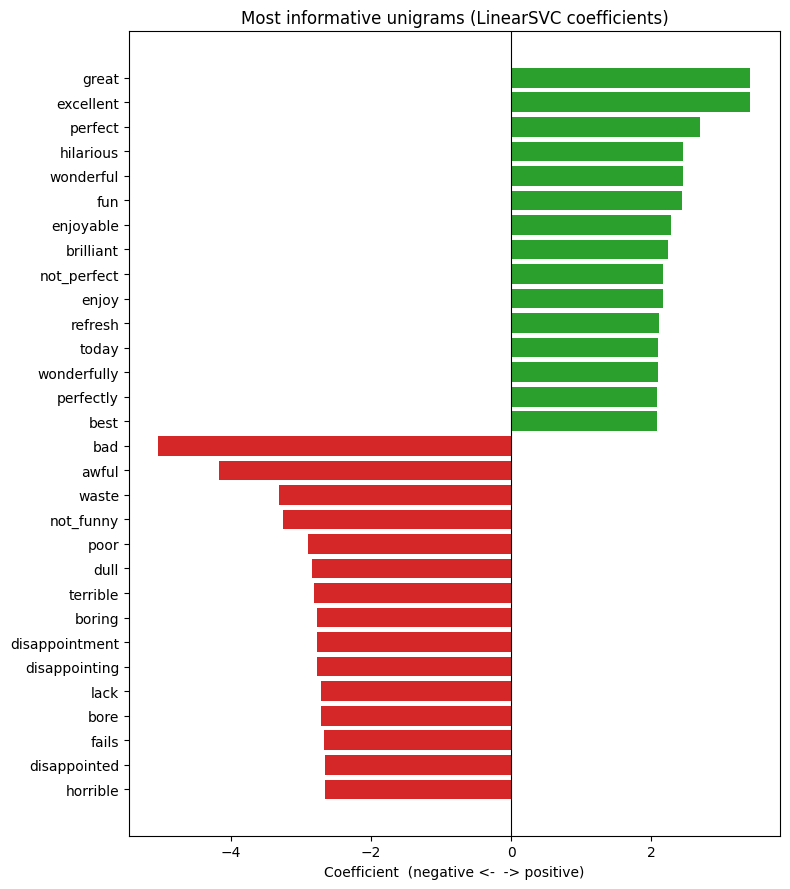

In [22]:
import numpy as np
import matplotlib.pyplot as plt

vec = best_pipe.named_steps['tfidf']
clf = best_pipe.named_steps['clf']
names = np.array(vec.get_feature_names_out())
coef = clf.coef_[0]          # positive value = pushes towards "positive" review

order = np.argsort(coef)
is_uni = np.array([' ' not in n for n in names])
is_bi  = np.array([n.count(' ') == 1 for n in names])

def top(mask, k=15):
    idx = [i for i in order if mask[i]]
    neg = [(names[i], round(coef[i], 2)) for i in idx[:k]]
    pos = [(names[i], round(coef[i], 2)) for i in idx[::-1][:k]]
    return pos, neg

for label, mask in [('UNIGRAMS', is_uni), ('BIGRAMS', is_bi)]:
    pos, neg = top(mask)
    print(f"\n=== Top 15 {label} -> POSITIVE ===")
    print(pos)
    print(f"\n=== Top 15 {label} -> NEGATIVE ===")
    print(neg)

# chart: top 15 unigrams each side
pos, neg = top(is_uni)
words = [w for w, _ in neg[::-1]] + [w for w, _ in pos[::-1]]
vals  = [v for _, v in neg[::-1]] + [v for _, v in pos[::-1]]
colors = ['tab:red'] * len(neg) + ['tab:green'] * len(pos)

plt.figure(figsize=(8, 9))
plt.barh(words, vals, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Most informative unigrams (LinearSVC coefficients)')
plt.xlabel('Coefficient  (negative <-  -> positive)')
plt.tight_layout()
plt.savefig('/kaggle/working/informative_words.png', dpi=150)
plt.show()

In [24]:
idx_of = {n: i for i, n in enumerate(names)}

def c(word):
    return round(coef[idx_of[word]], 2) if word in idx_of else None

print("Word vs its negated token (coefficient; positive = positive review):\n")
print(f"{'word':10s} {'plain':>8s} {'not_ version':>14s}")
for w in ['good', 'bad', 'funny', 'worth', 'like', 'waste', 'great', 'work']:
    print(f"{w:10s} {str(c(w)):>8s} {str(c('not_' + w)):>14s}")

not_mask = np.array([n.startswith('not_') and ' ' not in n for n in names])
print("\nnot_ unigrams in the model vocabulary:", not_mask.sum())

idx = [i for i in order if not_mask[i]]
print("\nTop 12 not_ tokens -> NEGATIVE:")
print([(names[i], round(coef[i], 2)) for i in idx[:12]])
print("\nTop 12 not_ tokens -> POSITIVE:")
print([(names[i], round(coef[i], 2)) for i in idx[::-1][:12]])

Word vs its negated token (coefficient; positive = positive review):

word          plain   not_ version
good           1.72           -1.8
bad           -5.04          -0.49
funny          1.79          -3.26
worth          0.99          -2.45
like           0.51          -0.08
waste         -3.32          -2.32
great          3.42           0.12
work           0.26          -1.53

not_ unigrams in the model vocabulary: 823

Top 12 not_ tokens -> NEGATIVE:
[('not_funny', np.float64(-3.26)), ('not_worth', np.float64(-2.45)), ('not_waste', np.float64(-2.32)), ('not_recommend', np.float64(-2.31)), ('not_enough', np.float64(-2.23)), ('not_worst', np.float64(-1.8)), ('not_good', np.float64(-1.8)), ('not_interesting', np.float64(-1.7)), ('not_particularly', np.float64(-1.6)), ('not_close', np.float64(-1.55)), ('not_work', np.float64(-1.53)), ('not_story', np.float64(-1.52))]

Top 12 not_ tokens -> POSITIVE:
[('not_perfect', np.float64(2.17)), ('not_disappoint', np.float64(1.15)), ('not_mast

## Most Informative Features (LinearSVC coefficients, trigram + sublinear model)

- Top positive unigrams: great (3.42), excellent (3.42), perfect (2.70), hilarious, wonderful, fun. Top negative: bad (-5.04), awful (-4.18), waste (-3.32), not_funny (-3.26), poor, dull, terrible, boring.
- `bad` likely absorbs `worst`, because the lemmatizer maps worst -> bad.
- Top bigrams: "must see", "well worth", "highly recommend" (positive); "bad film", "waste time", "bad movie" (negative). Some bigrams (e.g. "walk around", "would good") are fragments left after stopword removal, not real phrases.

### Negation tokens
| word | plain | not_ version |
|---|---|---|
| good | +1.72 | -1.80 |
| funny | +1.79 | -3.26 |
| worth | +0.99 | -2.45 |
| work | +0.26 | -1.53 |
| bad | -5.04 | -0.49 |
| like | +0.51 | -0.08 |
| great | +3.42 | +0.12 |
| waste | -3.32 | -2.32 |

- Negation handling flips the sign for good, funny, worth and work.
- Not fully flipped: `not_bad` is only weakly negative (consistent with the manual inspection), `not_like` and `not_great` are near zero, and `not_waste` stays negative.
- The `not_` prefix also covers "no", "never" and "cannot", so tokens such as `not_story` likely partly reflect "no story", and `not_wait` "can't wait".
- Unexplained (not investigated): `not_perfect` (+2.17) and `today` (+2.10) are strongly positive.
- Coefficients show which way a feature leans, not that it is the cause; correlated features (e.g. `bad` and `bad film`) share weight.
- 

Confusion matrix (rows = actual, cols = predicted; order: negative, positive):
[[4521  479]
 [ 411 4589]]

Total errors: 890

              precision    recall  f1-score   support

    negative     0.9167    0.9042    0.9104      5000
    positive     0.9055    0.9178    0.9116      5000

    accuracy                         0.9110     10000
   macro avg     0.9111    0.9110    0.9110     10000
weighted avg     0.9111    0.9110    0.9110     10000



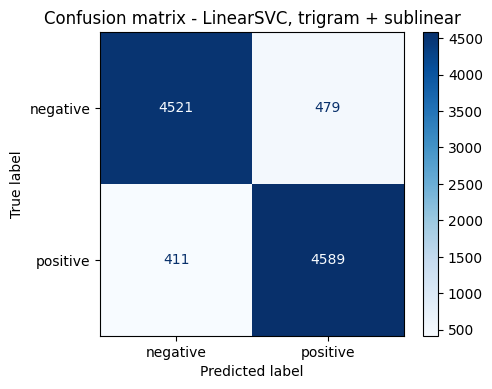

In [25]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix (rows = actual, cols = predicted; order: negative, positive):")
print(cm)
print("\nTotal errors:", cm[0,1] + cm[1,0])
print()
print(classification_report(y_test, y_pred, target_names=['negative', 'positive'], digits=4))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['negative', 'positive']).plot(
    ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion matrix - LinearSVC, trigram + sublinear')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()


## Confusion Matrix and Classification Report (LinearSVC, trigram + sublinear, C=1.0)

|  | Predicted negative | Predicted positive |
|---|---|---|
| Actual negative | 4521 | 479 |
| Actual positive | 411 | 4589 |

- Accuracy 91.10% (890 errors out of 10,000).
- Precision / recall / F1: negative 0.9167 / 0.9042 / 0.9104, positive 0.9055 / 0.9178 / 0.9116.
- The model makes slightly more false positives (479) than false negatives (411). A 68-review difference among 890 errors is small and may be chance, so this is only a mild tilt towards predicting "positive".

In [26]:
import re, textwrap
import numpy as np
import pandas as pd

test_df = df.loc[X_test.index].copy()
test_df['margin'] = best_pipe.decision_function(X_test)      # >0 means "positive"
test_df['pred'] = (test_df['margin'] > 0).astype(int)
test_df['correct'] = test_df['pred'] == test_df['label']
test_df['raw'] = test_df['review'].str.replace(r'<.*?>', ' ', regex=True)
test_df['n_words'] = test_df['raw'].str.split().str.len()

def show_confident(errors, n=5):
    for _, row in errors.head(n).iterrows():
        print(f"[margin {row['margin']:+.2f} | {row['n_words']} words | actual={row['sentiment']}]")
        print(textwrap.fill(row['raw'][:700].strip(), 110))
        print("-" * 110)

fp = test_df[(test_df['label'] == 0) & (test_df['pred'] == 1)].sort_values('margin', ascending=False)
fn = test_df[(test_df['label'] == 1) & (test_df['pred'] == 0)].sort_values('margin', ascending=True)

print(f"False positives: {len(fp)} | False negatives: {len(fn)}\n")
print("=== 5 MOST CONFIDENT FALSE POSITIVES (actual negative, predicted positive) ===\n")
show_confident(fp)
print("\n=== 5 MOST CONFIDENT FALSE NEGATIVES (actual positive, predicted negative) ===\n")
show_confident(fn)

# accuracy by review length
bins = [0, 100, 200, 400, 100000]
labels = ['<100 words', '100-200', '200-400', '>400 words']
test_df['len_bin'] = pd.cut(test_df['n_words'], bins=bins, labels=labels)
by_len = test_df.groupby('len_bin', observed=True)['correct'].agg(['count', 'mean'])
by_len['accuracy_%'] = (by_len['mean'] * 100).round(2)
print("\nAccuracy by review length:")
print(by_len[['count', 'accuracy_%']])

# how confident are the model's errors vs its correct answers?
print("\nMedian |margin|  correct:", round(test_df[test_df['correct']]['margin'].abs().median(), 2),
      "| wrong:", round(test_df[~test_df['correct']]['margin'].abs().median(), 2))

False positives: 479 | False negatives: 411

=== 5 MOST CONFIDENT FALSE POSITIVES (actual negative, predicted positive) ===

[margin +2.48 | 125 words | actual=negative]
This sleek, sexy movie is a must-see. Only upon multiple viewings can one truly understand the uniqueness of
this film. Personally I enjoy the narrator for his intelligent, no subject left untouched, style of narration.
The introduction grips you right away, and holds you at the edge of your seat throughout the film. He provides
wonderful insight into the world of the trainables and allows the audience to really 'connect' with internal
horror this film exhibits. The script itself holds the movie together wonderfully. Not only for kids, but the
elderly alike will gain a higher understanding of the trainables and the modern grasp that they have on the
sexual experience. Ahead of its time and g
--------------------------------------------------------------------------------------------------------------
[margin +1.75 | 12

## Error Analysis

Reviews were truncated to 700 characters when printed, so the final verdict of some long reviews was not visible. "Confident" means a large decision_function margin (LinearSVC gives no probabilities). The 10 examples are the most extreme errors, not a representative sample, and the categories below are my own tentative reading.

**Most confident false positives (actual negative, predicted positive)**
- Mixed sentiment: "A wonderful mini-series completely ruined by..." has strong positive words and one decisive complaint; a bag-of-words model cannot weigh which one decides the verdict.
- Hedged praise: "not a great film... but several hilarious moments".
- Three reviews read positive in the visible text (possible sarcasm, a verdict later in the text, or a label that disagrees with the text).

**Most confident false negatives (actual positive, predicted negative)**
- "So bad it's good" / guilty pleasure: negative vocabulary ("badly acted", "so bad", "lame") in a review that is positive overall.
- Two reviews read negative to me (possible label noise, or a verdict in the hidden part).

**Accuracy by review length:** <100 words 92.35% (n=1308), 100-200 91.07% (n=4704), 200-400 90.62% (n=2740), >400 90.95% (n=1248). Short reviews were not harder here; the gap between the shortest and longer bins is about 1.7 points, within a rough noise level of about ±0.75 points for the smallest bin.

**Confidence:** median |margin| is 1.07 for correct predictions and 0.29 for wrong ones, so most errors are borderline rather than confident.

Negation failure was not the clear cause in any of the 10 examples.

In [27]:
X_train_nn = X_train.str.replace('not_', 'not ', regex=False)
X_test_nn  = X_test.str.replace('not_', 'not ', regex=False)

rows = []
for name in ['Unigram+sublinear', 'Trigram+sublinear']:
    params = configs[name]
    for label, (xtr, xte) in {'with not_ tokens': (X_train, X_test),
                              'plain "not" kept separate': (X_train_nn, X_test_nn)}.items():
        vec = TfidfVectorizer(min_df=3, max_df=0.90, **params)
        A = vec.fit_transform(xtr)
        B = vec.transform(xte)
        svm = LinearSVC(C=1.0, random_state=42).fit(A, y_train)
        rows.append((name, label, accuracy_score(y_test, svm.predict(B)) * 100))

res = pd.DataFrame(rows, columns=['config', 'clean version', 'accuracy_%']).round(2)
print(res.to_string(index=False))

           config             clean version  accuracy_%
Unigram+sublinear          with not_ tokens       90.12
Unigram+sublinear plain "not" kept separate       89.63
Trigram+sublinear          with not_ tokens       91.10
Trigram+sublinear plain "not" kept separate       91.11


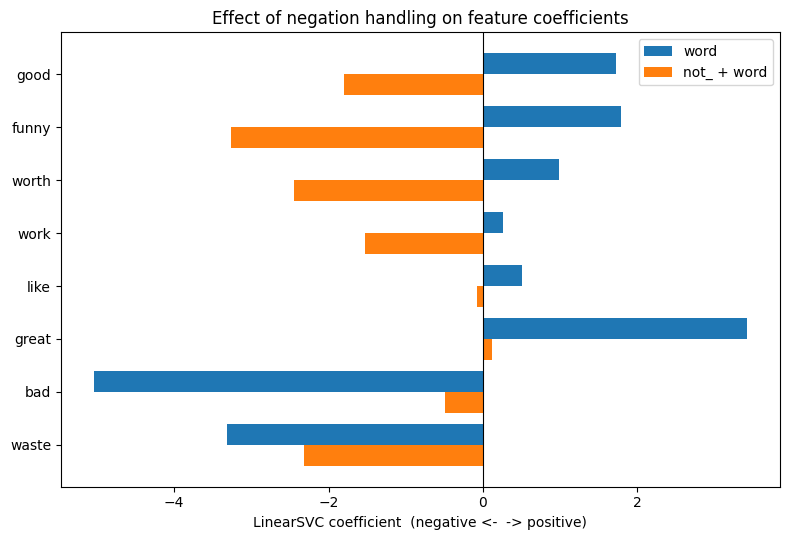

In [28]:
import numpy as np
import matplotlib.pyplot as plt

pairs = ['good', 'funny', 'worth', 'work', 'like', 'great', 'bad', 'waste']
plain = [coef[idx_of[w]] for w in pairs]
neg   = [coef[idx_of['not_' + w]] for w in pairs]

y = np.arange(len(pairs))
plt.figure(figsize=(8, 5.5))
plt.barh(y - 0.2, plain, height=0.4, label='word', color='tab:blue')
plt.barh(y + 0.2, neg,   height=0.4, label='not_ + word', color='tab:orange')
plt.yticks(y, pairs)
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.xlabel('LinearSVC coefficient  (negative <-  -> positive)')
plt.title('Effect of negation handling on feature coefficients')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/negation_tokens.png', dpi=150)
plt.show()

## Negation Handling Ablation (LinearSVC, same split)

| Config | With `not_` tokens | "not" kept as separate word | Difference |
|---|---|---|---|
| Unigram + sublinear | 90.12% | 89.63% | +0.49 |
| Trigram + sublinear | 91.10% | 91.11% | -0.01 |

- For unigrams, gluing "not" to the next word gave +0.49 points, slightly above the expected ±0.3 test noise but measured on a single split.
- For trigrams there was no accuracy difference. A likely explanation (not tested) is that bigrams and trigrams such as "not good" already capture negation.
- This ablation did not test removing negation words from the stopword list, which the guide treats as the key decision. It only compares `not_x` tokens against keeping `not` as a separate word.
- The coefficient analysis (good +1.72 vs not_good -1.80) shows the tokens behave as intended, but for the best model that did not translate into higher accuracy.

## Conclusions

**Best combination.** TF-IDF with trigrams (ngram_range=(1,3), 50,000 features, sublinear_tf=True) + LinearSVC (C=1.0): 91.10% on the held-out test set, 90.69% +/- 0.18 in 5-fold cross-validation over all 50,000 reviews. The more conservative figure is about 90.7%. The project guide states an expected range of 91-93% for this configuration, so the result sits at the bottom of that range.

**Benchmark.** The guide cites about 93-94% as the best classical result and about 95-96% for BERT-based models on IMDB. I did not verify these figures. This model is roughly 2-3 points below the classical figure.

**What each choice contributed** (single 80/20 split, test noise about +/-0.3 points):
- Bigrams: +0.86 points over unigrams, the clearest gain. Trigrams added only +0.12 more.
- Sublinear TF: +0.14 (LinearSVC), +0.26 (LogReg), +0.26 (NB). Consistent in direction but small.
- Total unigram -> trigram gain with LinearSVC: +1.12 points (the guide's "~9%" claim does not match the data).
- Algorithms: LinearSVC and LogReg are close (within about 0.5 points); MultinomialNB trails by 2-3 points but gains the most from n-grams (+1.96).
- Tuning: C=1.0 was best (CV 90.46%), C=0.1 statistically tied, C=0.01 underfits (87.41%), C=10 loses accuracy (89.21%).

**Negation handling.** `not_x` tokens flip the sign of key features (good +1.72 vs not_good -1.80; funny +1.79 vs not_funny -3.26), and gave +0.49 points for unigrams. For trigrams they made no accuracy difference (-0.01), probably because n-grams already capture "not good". The guide's stronger claim, that removing negation words from stopwords is the most important decision, was not tested directly.

**Error analysis.** 890 errors in 10,000 (479 false positives, 411 false negatives). Most errors are borderline (median |margin| 0.29 vs 1.07 for correct predictions). The most confident errors I could read were mixed-sentiment reviews, "so bad it's good" guilty pleasures, and a few that read as the opposite of their label, which may be label noise. Short reviews were not harder (92.35% under 100 words vs 90.62% for 200-400 words). Sarcasm was not clearly visible in the 10 examples inspected.

**Limitations of bag-of-words.** It cannot tell whose opinion a negation refers to (`not_like` appears in both classes almost equally), cannot see that a "but" reverses the sentiment, and treats "so bad it's good" as negative. Coefficients show correlation, not cause. All comparisons use one split, so small differences are inconclusive.

**What deep learning could address.** Per the guide, BERT-style models reach about 95-96% because they model context: contrast structures, long-range dependencies and whose opinion is being expressed. I did not test this.